In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import _tree

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('diabetes.csv')

# Outcome: 1 = diabetic, 0 = non-diabetic
X = df.drop(columns=['Outcome'])
y = df['Outcome'].rename('target')
feature_names = list(X.columns)

print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Dataset shape: (768, 8)
Class distribution:
 target
0    500
1    268
Name: count, dtype: int64

Train: 614 | Test: 154


Random Forest
Accuracy : 0.7273
F1 Score : 0.5625
              precision    recall  f1-score   support

Non-diabetic       0.76      0.85      0.80       100
    Diabetic       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



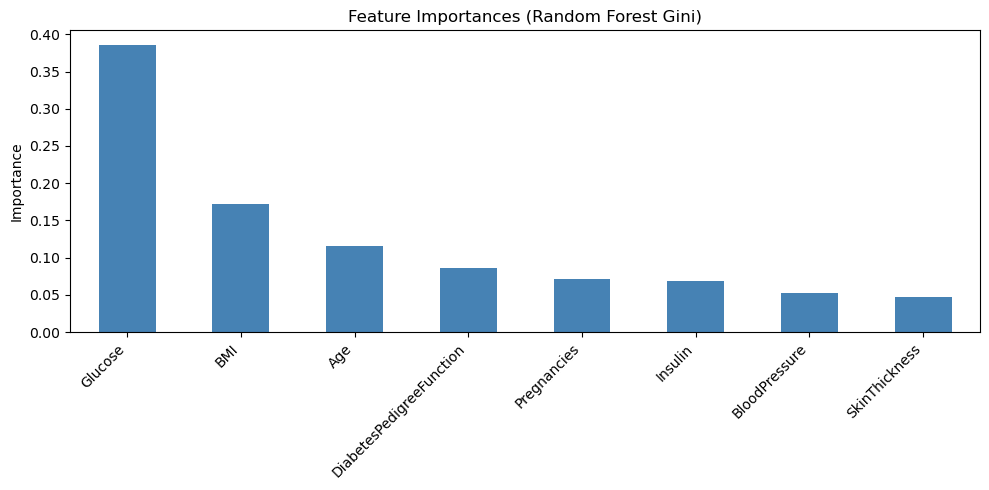

In [23]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print("Random Forest")
print(f"Accuracy : {rf_acc:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(classification_report(y_test, rf_preds,
      target_names=["Non-diabetic", "Diabetic"]))

importances = pd.Series(
    rf.feature_importances_, index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title("Feature Importances (Random Forest Gini)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('pima_rf_importances.png', dpi=150)
plt.show()


In [ ]:
def extract_rules_from_tree(tree, feature_names):
    tree_ = tree.tree_
    features = [feature_names[i] if i != _tree.TREE_UNDEFINED
                else "undefined" for i in tree_.feature]
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            class_counts = tree_.value[node][0]
            prediction = int(np.argmax(class_counts))
            rules.append({
                'conditions': list(conditions),
                'prediction': prediction,
                'samples': int(tree_.n_node_samples[node]),
                'impurity': float(tree_.impurity[node])
            })
            return
        feat = features[node]
        threshold = tree_.threshold[node]
        recurse(tree_.children_left[node],
                conditions + [f"{feat} <= {threshold:.4f}"])
        recurse(tree_.children_right[node],
                conditions + [f"{feat} > {threshold:.4f}"])

    recurse(0, [])
    return rules


all_rules = []
for estimator in rf.estimators_:
    all_rules.extend(extract_rules_from_tree(estimator, feature_names))


clean_rules = [r for r in all_rules if r['impurity'] < 0.1]
print(f"Total rules extracted : {len(all_rules)}")
print(f"After purity filter   : {len(clean_rules)}")
print(f"\nExample rule:")
print(f"  IF {chr(10)+'  AND '.join(clean_rules[0]['conditions'])}")
print(f"  THEN -> {'Diabetic' if clean_rules[0]['prediction']==1 else 'Non-diabetic'}")


Total rules extracted : 2442
After purity filter   : 1300

Example rule:
  IF 
BMI <= 28.8000  AND Insulin <= 343.0000  AND Glucose <= 145.5000  AND BMI <= 9.1000  AND DiabetesPedigreeFunction <= 0.2440
  THEN -> Diabetic


In [25]:
def instance_satisfies_rule(row, conditions):
    for condition in conditions:
        if ' <= ' in condition:
            feat, thresh = condition.split(' <= ')
            if not (row[feat.strip()] <= float(thresh)):
                return False
        elif ' > ' in condition:
            feat, thresh = condition.split(' > ')
            if not (row[feat.strip()] > float(thresh)):
                return False
    return True


def build_indicator_matrix(rules, X_df):
    N = len(X_df)
    K = len(rules)
    A = np.zeros((N, K), dtype=np.float32)
    for k, rule in enumerate(rules):
        if k % 500 == 0:
            print(f"  Rule {k}/{K}...")
        for i, (_, row) in enumerate(X_df.iterrows()):
            if instance_satisfies_rule(row, rule['conditions']):
                A[i, k] = 1.0
    return A


print("Building A_train matrix...")
A_train = build_indicator_matrix(clean_rules, X_train.reset_index(drop=True))
print("Building A_test matrix...")
A_test = build_indicator_matrix(clean_rules, X_test.reset_index(drop=True))
print(f"\nA_train shape: {A_train.shape}")
print(f"A_test shape : {A_test.shape}")
print(f"Matrix density: {A_train.mean():.4f}")


Building A_train matrix...
  Rule 0/1300...
  Rule 500/1300...
  Rule 1000/1300...
Building A_test matrix...
  Rule 0/1300...
  Rule 500/1300...
  Rule 1000/1300...

A_train shape: (614, 1300)
A_test shape : (154, 1300)
Matrix density: 0.0257


In [43]:
print("Running LassoCV to find a good lambda...")
lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42, n_alphas=100)
lasso_cv.fit(A_train, y_train.values)
best_alpha = lasso_cv.alpha_
print(f"Best lambda: {best_alpha:.6f}")

# multiplier sweep storing results for the grpah 
multipliers = [1, 2, 5, 10, 20, 30]
rule_counts = []
accuracies = []

for m in multipliers:
    L = Lasso(alpha=best_alpha * m, max_iter=10000)
    L.fit(A_train, y_train.values)
    n = int(np.sum(L.coef_ != 0))
    preds = (L.predict(A_test) >= 0.5).astype(int)
    acc = accuracy_score(y_test, preds)
    rule_counts.append(n)
    accuracies.append(acc)
    print(f"Lambda x{m:>3} -> {n:>4} rules  Accuracy: {acc:.4f}")


Running LassoCV to find a good lambda...
Best lambda: 0.001530
Lambda x  1 ->  187 rules  Accuracy: 0.7468
Lambda x  2 ->  109 rules  Accuracy: 0.7468
Lambda x  5 ->   43 rules  Accuracy: 0.7338
Lambda x 10 ->   20 rules  Accuracy: 0.7078
Lambda x 20 ->   13 rules  Accuracy: 0.7078
Lambda x 30 ->    7 rules  Accuracy: 0.7078


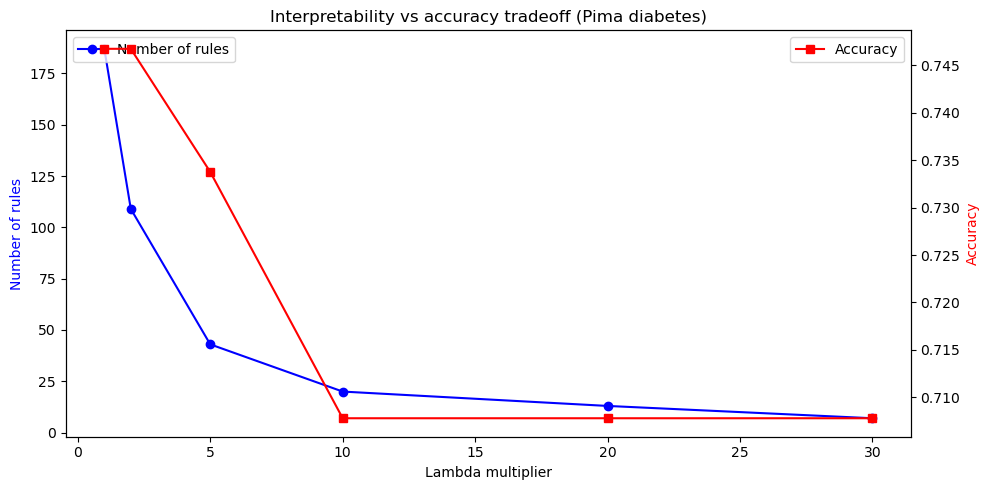

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(multipliers, rule_counts, 'bo-', label='Number of rules')
ax2.plot(multipliers, accuracies, 'rs-', label='Accuracy')

ax1.set_xlabel('Lambda multiplier')
ax1.set_ylabel('Number of rules', color='blue')
ax2.set_ylabel('Accuracy', color='red')

plt.title('Interpretability vs accuracy tradeoff (Pima diabetes)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pima_tradeoff_curve.png', dpi=150)
plt.show()


In [28]:
# multiplier from the tradeoff curve above
chosen_multiplier = 10

lasso = Lasso(alpha=best_alpha * chosen_multiplier, max_iter=10000)
lasso.fit(A_train, y_train.values)

nonzero_mask = lasso.coef_ != 0
nonzero_indices = np.where(nonzero_mask)[0]
nonzero_weights = lasso.coef_[nonzero_mask]

sparse_rules = []
for idx, weight in zip(nonzero_indices, nonzero_weights):
    rule = clean_rules[idx].copy()
    rule['weight'] = weight
    sparse_rules.append(rule)
sparse_rules.sort(key=lambda r: abs(r['weight']), reverse=True)

print(f"Final rule count : {len(sparse_rules)}")


Final rule count : 20


In [29]:
def predict_with_rules(sparse_rules, X_df, intercept):
    predictions = []
    fired_counts = []
    for _, row in X_df.iterrows():
        score = intercept
        fired = 0
        for rule in sparse_rules:
            if instance_satisfies_rule(row, rule['conditions']):
                score += rule['weight']
                fired += 1
        predictions.append(1 if score >= 0.5 else 0)
        fired_counts.append(fired)
    return np.array(predictions), fired_counts


print("Predicting with sparse rules...")
rule_preds, fired_counts = predict_with_rules(
    sparse_rules, X_test.reset_index(drop=True), lasso.intercept_
)
rule_acc = accuracy_score(y_test, rule_preds)
rule_f1 = f1_score(y_test, rule_preds)

print("\nPerformance comparison")
print(f"{'Model':<40} {'Acc':>8} {'F1':>8}")
print(f"{'Random Forest (100 trees)':<40} "
      f"{rf_acc:>8.4f} {rf_f1:>8.4f}")
print(f"{'Sparse Rules (' + str(len(sparse_rules)) + ' rules)':<40} "
      f"{rule_acc:>8.4f} {rule_f1:>8.4f}")
print(f"\nAccuracy cost of interpretability: "
      f"{(rf_acc-rule_acc)*100:.2f}%")
print(classification_report(y_test, rule_preds,
      target_names=["Non-diabetic", "Diabetic"]))


Predicting with sparse rules...

Performance comparison
Model                                         Acc       F1
Random Forest (100 trees)                  0.7273   0.5625
Sparse Rules (20 rules)                    0.7078   0.3836

Accuracy cost of interpretability: 1.95%
              precision    recall  f1-score   support

Non-diabetic       0.70      0.95      0.81       100
    Diabetic       0.74      0.26      0.38        54

    accuracy                           0.71       154
   macro avg       0.72      0.60      0.60       154
weighted avg       0.72      0.71      0.66       154



Signal vs noise
Features in sparse rules : 8
Top RF Gini features     : 8
Overlap                  : 8
Overlap %                : 100%

Features both methods agree on:
  - Age
  - BMI
  - BloodPressure
  - DiabetesPedigreeFunction
  - Glucose
  - Insulin
  - Pregnancies
  - SkinThickness


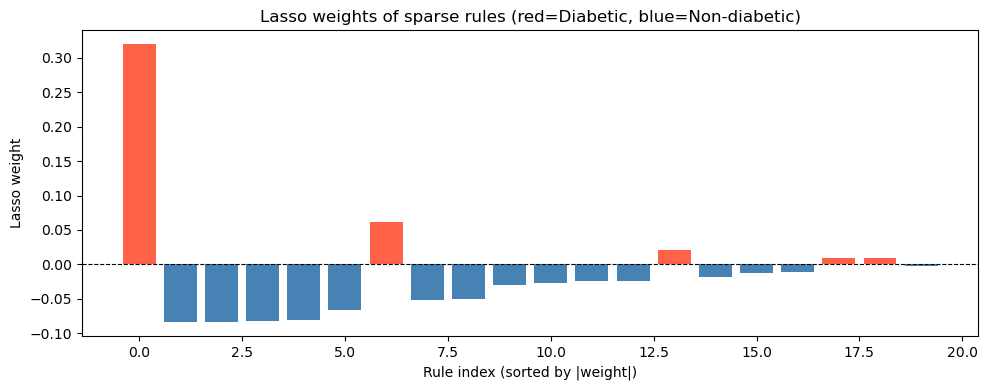

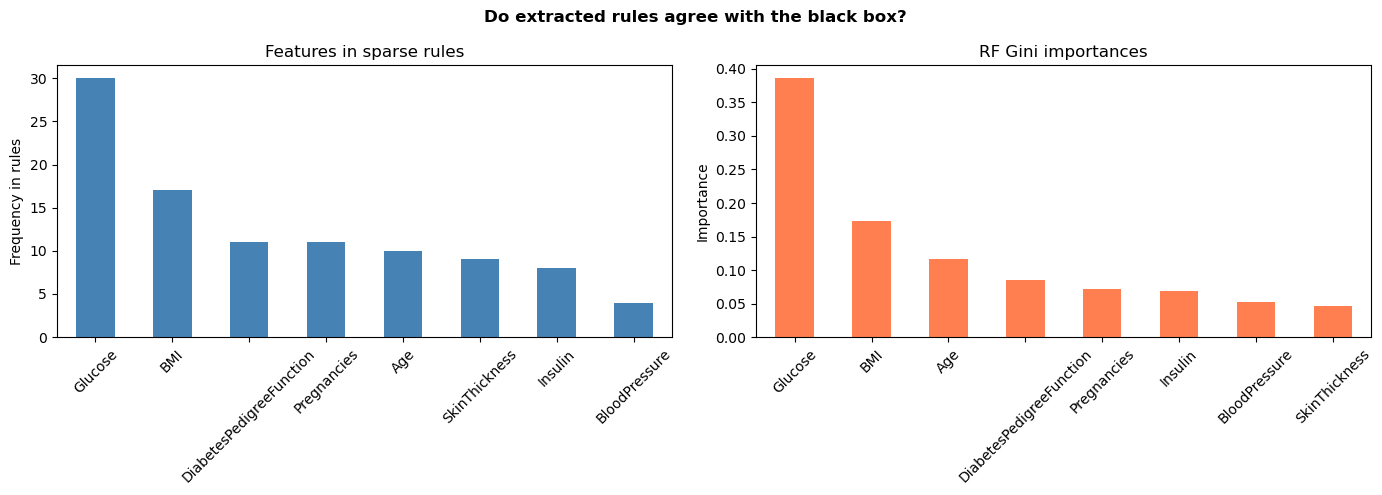


Summary
Started with         : 100-tree Random Forest
Extracted            : 2442 candidate rules
After purity filter  : 1300 clean rules
After Lasso (L1)     : 20 interpretable rules
Avg conditions/rule  : 5.0
RF accuracy          : 0.7273
Rule set accuracy    : 0.7078
Accuracy retained    : 97.3%
Rules firing/instance: 3.7 on average


In [ ]:

rule_features = []
for rule in sparse_rules:
    for cond in rule['conditions']:
        feat = cond.split(' <= ')[0].strip() if ' <= ' in cond \
               else cond.split(' > ')[0].strip()
        rule_features.append(feat)
rule_feat_counts = pd.Series(rule_features).value_counts()

rule_feat_set = set(rule_feat_counts.index)
rf_feat_set = set(importances.head(len(rule_feat_set)).index)
overlap = rule_feat_set & rf_feat_set

print("Signal vs noise")
print(f"Features in sparse rules : {len(rule_feat_set)}")
print(f"Top RF Gini features     : {len(rf_feat_set)}")
print(f"Overlap                  : {len(overlap)}")
print(f"Overlap %                : "
      f"{100*len(overlap)/len(rule_feat_set):.0f}%")
print(f"\nFeatures both methods agree on:")
for f in sorted(overlap):
    print(f"  - {f}")

# rule weights
plt.figure(figsize=(10, 4))
weights = [r['weight'] for r in sparse_rules]
colors = ['tomato' if r['prediction']==1 else 'steelblue'
          for r in sparse_rules]
plt.bar(range(len(sparse_rules)), weights, color=colors)
plt.axhline(0, color='black', lw=0.8, ls='--')
plt.xlabel("Rule index (sorted by |weight|)")
plt.ylabel("Lasso weight")
plt.title("Lasso weights of sparse rules (red=Diabetic, blue=Non-diabetic)")
plt.tight_layout()
plt.savefig('pima_rule_weights.png', dpi=150)
plt.show()

# features in rules vs RF importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rule_feat_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Features in sparse rules")
axes[0].set_ylabel("Frequency in rules")
axes[0].tick_params(axis='x', rotation=45)

importances.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("RF Gini importances")
axes[1].set_ylabel("Importance")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Do extracted rules agree with the black box?",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pima_signal_vs_noise.png', dpi=150)
plt.show()

avg_conditions = np.mean([len(r['conditions']) for r in sparse_rules])
print("\nSummary")
print(f"Started with         : 100-tree Random Forest")
print(f"Extracted            : {len(all_rules)} candidate rules")
print(f"After purity filter  : {len(clean_rules)} clean rules")
print(f"After Lasso (L1)     : {len(sparse_rules)} interpretable rules")
print(f"Avg conditions/rule  : {avg_conditions:.1f}")
print(f"RF accuracy          : {rf_acc:.4f}")
print(f"Rule set accuracy    : {rule_acc:.4f}")
print(f"Accuracy retained    : {rule_acc/rf_acc*100:.1f}%")
print(f"Rules firing/instance: {np.mean(fired_counts):.1f} on average")


In [ ]:

test_patient = {
    'Pregnancies'              : 6,
    'Glucose'                  : 148,
    'BloodPressure'            : 72,
    'SkinThickness'            : 35,
    'Insulin'                  : 0,
    'BMI'                      : 33.6,
    'DiabetesPedigreeFunction' : 0.627,
    'Age'                      : 50,
}

row = pd.Series(test_patient)
score = lasso.intercept_
fired_rules = []

for rule in sparse_rules:
    if instance_satisfies_rule(row, rule['conditions']):
        score += rule['weight']
        fired_rules.append(rule)

prediction = 'DIABETIC' if score >= 0.5 else 'NON-DIABETIC'
confidence = abs(score - 0.5) * 100

print(f"PREDICTION  :  {prediction}")
print(f"Confidence  :  {confidence:.1f}  (distance from boundary)")
print(f"Raw score   :  {score:.4f}  (>= 0.5 = Diabetic)")

print(f"\n{len(fired_rules)} rules fired for this patient:\n")
for i, rule in enumerate(fired_rules):
    label = 'DIABETIC' if rule['prediction'] == 1 else 'NON-DIABETIC'
    direction = 'pushing toward DIABETIC' if rule['weight'] > 0 \
                else 'pushing toward NON-DIABETIC'
    print(f"Rule {i+1} [{label}] weight={rule['weight']:+.4f} {direction}")
    for cond in rule['conditions']:
        print(f"   IF {cond}")
    print()

# now we test on a known non-diabetic patient from the test set
print("\nKnown non-diabetic patient from test set")

nondiab_idx = y_test[y_test == 0].index[0]
nondiab_row = X_test.loc[nondiab_idx]
score2 = lasso.intercept_
fired_rules2 = []

for rule in sparse_rules:
    if instance_satisfies_rule(nondiab_row, rule['conditions']):
        score2 += rule['weight']
        fired_rules2.append(rule)

pred2 = 'DIABETIC' if score2 >= 0.5 else 'NON-DIABETIC'
print(f"PREDICTION  : {pred2}")
print(f"Raw score   : {score2:.4f}")
print(f"Rules fired : {len(fired_rules2)}")

# and a known diabetic patient
print("\nKnown diabetic patient from test set")

diab_idx = y_test[y_test == 1].index[0]
diab_row = X_test.loc[diab_idx]
score3 = lasso.intercept_
fired_rules3 = []

for rule in sparse_rules:
    if instance_satisfies_rule(diab_row, rule['conditions']):
        score3 += rule['weight']
        fired_rules3.append(rule)

pred3 = 'DIABETIC' if score3 >= 0.5 else 'NON-DIABETIC'
print(f"PREDICTION  : {pred3}")
print(f"Raw score   : {score3:.4f}")
print(f"Rules fired : {len(fired_rules3)}")


PREDICTION  :  NON-DIABETIC
Confidence  :  5.4  (distance from boundary)
Raw score   :  0.4457  (>= 0.5 = Diabetic)

1 rules fired for this patient:

Rule 1 [DIABETIC] weight=+0.0089 pushing toward DIABETIC
   IF Glucose > 127.5000
   IF BMI > 29.9500
   IF BloodPressure <= 73.0000
   IF DiabetesPedigreeFunction > 0.3470
   IF SkinThickness <= 41.5000


Known non-diabetic patient from test set
PREDICTION  : DIABETIC
Raw score   : 0.7563
Rules fired : 1

Known diabetic patient from test set
PREDICTION  : NON-DIABETIC
Raw score   : 0.3425
Rules fired : 2


In [32]:
#which rules fired for the non-diabetic patient
print("Known non-diabetic patient")
print(f"PREDICTION  : {pred2}")
print(f"Raw score   : {score2:.4f}")
print(f"Rules fired : {len(fired_rules2)}\n")

for i, rule in enumerate(fired_rules2):
    label = 'DIABETIC' if rule['prediction'] == 1 else 'NON-DIABETIC'
    direction = 'pushing toward DIABETIC' if rule['weight'] > 0 \
                else 'pushing toward NON-DIABETIC'
    print(f"Rule {i+1} [{label}] weight={rule['weight']:+.4f} {direction}")
    for cond in rule['conditions']:
        print(f"   IF {cond}")
    print()

#  for the diabetic patient
print("\nKnown diabetic patient")
print(f"PREDICTION  : {pred3}")
print(f"Raw score   : {score3:.4f}")
print(f"Rules fired : {len(fired_rules3)}\n")

for i, rule in enumerate(fired_rules3):
    label = 'DIABETIC' if rule['prediction'] == 1 else 'NON-DIABETIC'
    direction = 'pushing toward DIABETIC' if rule['weight'] > 0 \
                else 'pushing toward NON-DIABETIC'
    print(f"Rule {i+1} [{label}] weight={rule['weight']:+.4f} {direction}")
    for cond in rule['conditions']:
        print(f"   IF {cond}")
    print()


Known non-diabetic patient
PREDICTION  : DIABETIC
Raw score   : 0.7563
Rules fired : 1

Rule 1 [DIABETIC] weight=+0.3196 pushing toward DIABETIC
   IF Glucose > 154.5000
   IF DiabetesPedigreeFunction > 0.1345
   IF BMI > 23.1500
   IF Age <= 57.5000
   IF Insulin <= 544.0000


Known diabetic patient
PREDICTION  : NON-DIABETIC
Raw score   : 0.3425
Rules fired : 2

Rule 1 [NON-DIABETIC] weight=-0.0666 pushing toward NON-DIABETIC
   IF Glucose <= 151.5000
   IF Pregnancies <= 7.5000
   IF BMI <= 28.8500
   IF SkinThickness <= 37.0000
   IF Glucose <= 138.0000

Rule 2 [NON-DIABETIC] weight=-0.0276 pushing toward NON-DIABETIC
   IF BMI <= 29.6500
   IF Age <= 39.5000
   IF Pregnancies <= 7.5000
   IF Glucose <= 144.5000
   IF Pregnancies > 0.5000



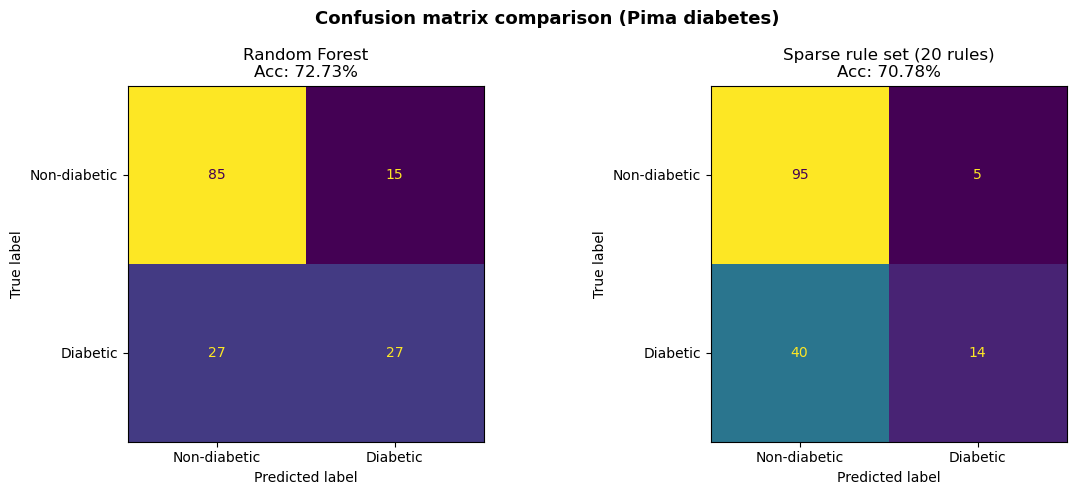

All 20 extracted rules

Rule 01 | DIABETIC | weight=+0.3196
  Conditions:
    - Glucose > 154.5000
    - DiabetesPedigreeFunction > 0.1345
    - BMI > 23.1500
    - Age <= 57.5000
    - Insulin <= 544.0000
  -> Prediction: DIABETIC

Rule 02 | NON-DIABETIC | weight=-0.0840
  Conditions:
    - BMI > 29.8500
    - Age <= 35.5000
    - DiabetesPedigreeFunction <= 0.5095
    - Glucose <= 139.0000
    - BloodPressure <= 89.0000
  -> Prediction: NON-DIABETIC

Rule 03 | NON-DIABETIC | weight=-0.0836
  Conditions:
    - Glucose <= 127.5000
    - Glucose > 28.0000
    - Glucose <= 96.5000
    - DiabetesPedigreeFunction <= 1.2715
    - BMI <= 50.8500
  -> Prediction: NON-DIABETIC

Rule 04 | NON-DIABETIC | weight=-0.0822
  Conditions:
    - Age <= 26.5000
    - Pregnancies > 0.5000
    - SkinThickness <= 32.5000
    - BMI <= 42.8000
    - Pregnancies <= 7.5000
  -> Prediction: NON-DIABETIC

Rule 05 | NON-DIABETIC | weight=-0.0810
  Conditions:
    - BMI <= 29.6500
    - SkinThickness <= 37.0000
  

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y_test, rf_preds)
cm2 = confusion_matrix(y_test, rule_preds)

ConfusionMatrixDisplay(cm1, display_labels=['Non-diabetic', 'Diabetic'])\
    .plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Random Forest\nAcc: {rf_acc*100:.2f}%')

ConfusionMatrixDisplay(cm2, display_labels=['Non-diabetic', 'Diabetic'])\
    .plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Sparse rule set ({len(sparse_rules)} rules)\n'
                  f'Acc: {rule_acc*100:.2f}%')

plt.suptitle('Confusion matrix comparison (Pima diabetes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pima_confusion_matrices.png', dpi=150)
plt.show()

# full list of selected rules
print(f"All {len(sparse_rules)} extracted rules")
for i, rule in enumerate(sparse_rules):
    label = 'DIABETIC' if rule['prediction'] == 1 else 'NON-DIABETIC'
    print(f"\nRule {i+1:02d} | {label} | weight={rule['weight']:+.4f}")
    print("  Conditions:")
    for cond in rule['conditions']:
        print(f"    - {cond}")
    print(f"  -> Prediction: {label}")


In [34]:


from sklearn.utils.class_weight import compute_class_weight

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',   
)
rf_balanced.fit(X_train, y_train)

rf_b_preds = rf_balanced.predict(X_test)
rf_b_acc = accuracy_score(y_test, rf_b_preds)
rf_b_f1 = f1_score(y_test, rf_b_preds)


print("Random Forest comparison")
print(f"{'Model':<35} {'Acc':>7} {'F1':>7}")
print(f"{'Unbalanced RF (original)':<35} {rf_acc:>7.4f} {rf_f1:>7.4f}")
print(f"{'Balanced RF (class_weight)':<35} {rf_b_acc:>7.4f} {rf_b_f1:>7.4f}")
print()
print("Per-class report (balanced RF):")
print(classification_report(y_test, rf_b_preds,
      target_names=["Non-diabetic", "Diabetic"]))


Random Forest comparison
Model                                   Acc      F1
Unbalanced RF (original)             0.7273  0.5625
Balanced RF (class_weight)           0.7727  0.7009

Per-class report (balanced RF):
              precision    recall  f1-score   support

Non-diabetic       0.86      0.78      0.82       100
    Diabetic       0.65      0.76      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



In [35]:


all_rules_b = []
for estimator in rf_balanced.estimators_:
    all_rules_b.extend(extract_rules_from_tree(estimator, feature_names))


clean_rules_b = [r for r in all_rules_b if r['impurity'] < 0.1]
print(f"Total rules extracted (balanced): {len(all_rules_b)}")
print(f"After purity filter             : {len(clean_rules_b)}")


Total rules extracted (balanced): 2525
After purity filter             : 1325


In [36]:


print("Building A_train_b matrix...")
A_train_b = build_indicator_matrix(clean_rules_b, X_train.reset_index(drop=True))
print("Building A_test_b matrix...")
A_test_b = build_indicator_matrix(clean_rules_b, X_test.reset_index(drop=True))
print(f"\nA_train_b shape: {A_train_b.shape}")
print(f"A_test_b shape : {A_test_b.shape}")
print(f"Matrix density: {A_train_b.mean():.4f}")


Building A_train_b matrix...
  Rule 0/1325...
  Rule 500/1325...
  Rule 1000/1325...
Building A_test_b matrix...
  Rule 0/1325...
  Rule 500/1325...
  Rule 1000/1325...

A_train_b shape: (614, 1325)
A_test_b shape : (154, 1325)
Matrix density: 0.0232


In [44]:


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train.values,
)
sample_weight = np.where(y_train.values == 1, class_weights[1], class_weights[0])
print(f"Class weights -> non-diabetic: {class_weights[0]:.4f}, diabetic: {class_weights[1]:.4f}")


print("\nRunning LassoCV (balanced)...")
lasso_cv_b = LassoCV(cv=5, max_iter=10000, random_state=42, n_alphas=100)
lasso_cv_b.fit(A_train_b, y_train.values, sample_weight=sample_weight)
best_alpha_b = lasso_cv_b.alpha_
print(f"Best lambda (balanced): {best_alpha_b:.6f}")


multipliers_b = [1, 2, 5, 10, 20, 30]
rule_counts_b = []
accuracies_b = []
f1_scores_b = []

for m in multipliers_b:
    L = Lasso(alpha=best_alpha_b * m, max_iter=10000)
    L.fit(A_train_b, y_train.values, sample_weight=sample_weight)
    n = int(np.sum(L.coef_ != 0))
    preds = (L.predict(A_test_b) >= 0.5).astype(int)
    acc = accuracy_score(y_test, preds)
    f1v = f1_score(y_test, preds)
    rule_counts_b.append(n)
    accuracies_b.append(acc)
    f1_scores_b.append(f1v)
    print(f"Lambda x{m:>3} -> {n:>4} rules  Acc: {acc:.4f}  F1: {f1v:.4f}")


Class weights -> non-diabetic: 0.7675, diabetic: 1.4346

Running LassoCV (balanced)...
Best lambda (balanced): 0.001166
Lambda x  1 ->  243 rules  Acc: 0.7597  F1: 0.6606
Lambda x  2 ->  149 rules  Acc: 0.7727  F1: 0.7009
Lambda x  5 ->   68 rules  Acc: 0.7273  F1: 0.6719
Lambda x 10 ->   32 rules  Acc: 0.7532  F1: 0.7031
Lambda x 20 ->   14 rules  Acc: 0.7143  F1: 0.6765
Lambda x 30 ->   11 rules  Acc: 0.6818  F1: 0.6525


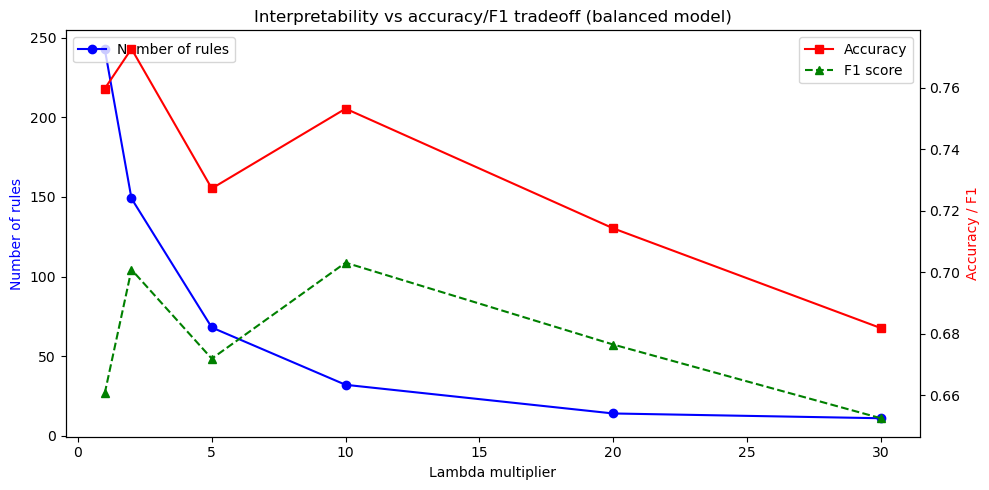

In [38]:


fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(multipliers_b, rule_counts_b, 'bo-', label='Number of rules')
ax2.plot(multipliers_b, accuracies_b, 'rs-', label='Accuracy')
ax2.plot(multipliers_b, f1_scores_b, 'g^--', label='F1 score')

ax1.set_xlabel('Lambda multiplier')
ax1.set_ylabel('Number of rules', color='blue')
ax2.set_ylabel('Accuracy / F1', color='red')

plt.title('Interpretability vs accuracy/F1 tradeoff (balanced model)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pima_balanced_tradeoff_curve.png', dpi=150)
plt.show()


In [39]:

chosen_multiplier_b = 10

lasso_b = Lasso(alpha=best_alpha_b * chosen_multiplier_b, max_iter=10000)
lasso_b.fit(A_train_b, y_train.values, sample_weight=sample_weight)


nonzero_mask_b = lasso_b.coef_ != 0
nonzero_indices_b = np.where(nonzero_mask_b)[0]
nonzero_weights_b = lasso_b.coef_[nonzero_mask_b]

sparse_rules_b = []
for idx, weight in zip(nonzero_indices_b, nonzero_weights_b):
    rule = clean_rules_b[idx].copy()
    rule['weight'] = weight
    sparse_rules_b.append(rule)
sparse_rules_b.sort(key=lambda r: abs(r['weight']), reverse=True)


n_diab_rules = sum(1 for r in sparse_rules_b if r['prediction'] == 1)
n_nondiab_rules = sum(1 for r in sparse_rules_b if r['prediction'] == 0)

print(f"Final balanced rule count : {len(sparse_rules_b)}")
print(f"  Diabetic-predicting     : {n_diab_rules}")
print(f"  Non-diabetic-predicting : {n_nondiab_rules}")


Final balanced rule count : 32
  Diabetic-predicting     : 11
  Non-diabetic-predicting : 21


In [45]:

print("Predicting with balanced sparse rules...")
rule_preds_b, fired_counts_b = predict_with_rules(
    sparse_rules_b, X_test.reset_index(drop=True), lasso_b.intercept_
)
rule_acc_b = accuracy_score(y_test, rule_preds_b)
rule_f1_b = f1_score(y_test, rule_preds_b)



print(f"{'Model':<40} {'Acc':>8} {'F1':>8}")

print(f"{'Unbalanced RF (original)':<40} {rf_acc:>8.4f} {rf_f1:>8.4f}")
print(f"{'Unbalanced sparse rules (' + str(len(sparse_rules)) + ' rules)':<40} "
      f"{rule_acc:>8.4f} {rule_f1:>8.4f}")
print(f"{'Balanced RF':<40} {rf_b_acc:>8.4f} {rf_b_f1:>8.4f}")
print(f"{'Balanced sparse rules (' + str(len(sparse_rules_b)) + ' rules)':<40} "
      f"{rule_acc_b:>8.4f} {rule_f1_b:>8.4f}")


print("\nPer-class report (balanced sparse rules):")
print(classification_report(y_test, rule_preds_b,
      target_names=["Non-diabetic", "Diabetic"]))


Predicting with balanced sparse rules...
Model                                         Acc       F1
Unbalanced RF (original)                   0.7273   0.5625
Unbalanced sparse rules (20 rules)         0.7078   0.3836
Balanced RF                                0.7727   0.7009
Balanced sparse rules (32 rules)           0.7532   0.7031

Per-class report (balanced sparse rules):
              precision    recall  f1-score   support

Non-diabetic       0.89      0.71      0.79       100
    Diabetic       0.61      0.83      0.70        54

    accuracy                           0.75       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.79      0.75      0.76       154



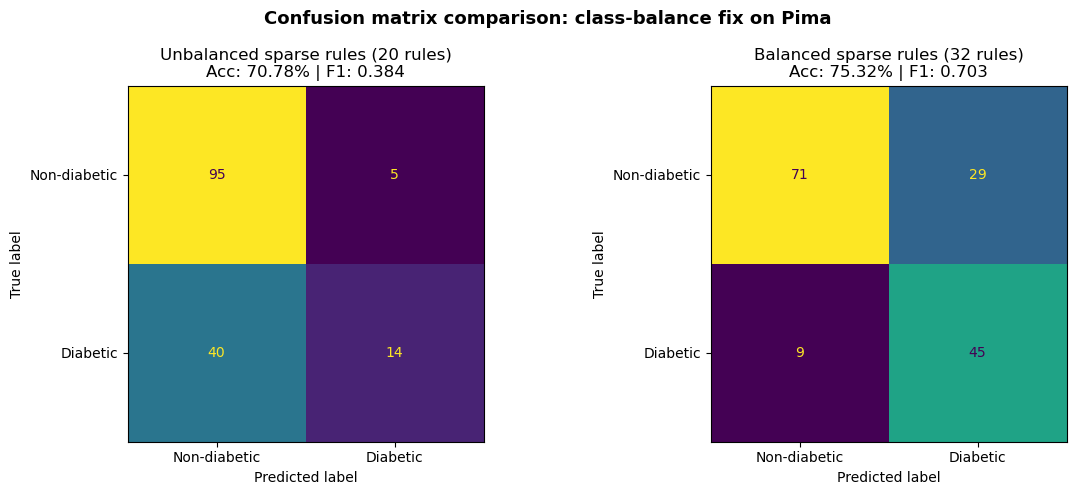

In [41]:


from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_unbalanced = confusion_matrix(y_test, rule_preds)
cm_balanced = confusion_matrix(y_test, rule_preds_b)

ConfusionMatrixDisplay(cm_unbalanced, display_labels=['Non-diabetic', 'Diabetic'])\
    .plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Unbalanced sparse rules ({len(sparse_rules)} rules)\n'
                  f'Acc: {rule_acc*100:.2f}% | F1: {rule_f1:.3f}')

ConfusionMatrixDisplay(cm_balanced, display_labels=['Non-diabetic', 'Diabetic'])\
    .plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Balanced sparse rules ({len(sparse_rules_b)} rules)\n'
                  f'Acc: {rule_acc_b*100:.2f}% | F1: {rule_f1_b:.3f}')

plt.suptitle('Confusion matrix comparison: class-balance fix on Pima',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pima_balanced_confusion_matrices.png', dpi=150)
plt.show()


In [47]:


print(f"All {len(sparse_rules_b)} extracted rules (balanced model)")
for i, rule in enumerate(sparse_rules_b):
    label = 'DIABETIC' if rule['prediction'] == 1 else 'NON-DIABETIC'
    print(f"\nRule {i+1:02d}  {label}  weight={rule['weight']:+.4f}")
    print("  Conditions:")
    for cond in rule['conditions']:
        print(f"    - {cond}")
    print(f"  -> Prediction: {label}")


from sklearn.metrics import recall_score

print("SUMMARY: limitation finding + fix")

print(f"{'Metric':<30} {'Unbalanced':>14} {'Balanced':>14}")

print(f"{'Sparse rule count':<30} {len(sparse_rules):>14} {len(sparse_rules_b):>14}")
print(f"{'Accuracy':<30} {rule_acc:>14.4f} {rule_acc_b:>14.4f}")
print(f"{'F1 score':<30} {rule_f1:>14.4f} {rule_f1_b:>14.4f}")
print(f"{'Diabetic recall':<30} "
      f"{recall_score(y_test, rule_preds, pos_label=1):>14.4f} "
      f"{recall_score(y_test, rule_preds_b, pos_label=1):>14.4f}")
print(f"{'Non-diabetic recall':<30} "
      f"{recall_score(y_test, rule_preds, pos_label=0):>14.4f} "
      f"{recall_score(y_test, rule_preds_b, pos_label=0):>14.4f}")
print(f"{'Diabetic-predicting rules':<30} "
      f"{sum(1 for r in sparse_rules if r['prediction']==1):>14} "
      f"{n_diab_rules:>14}")
print(f"{'Non-diabetic-predicting rules':<30} "
      f"{sum(1 for r in sparse_rules if r['prediction']==0):>14} "
      f"{n_nondiab_rules:>14}")


All 32 extracted rules (balanced model)

Rule 01  DIABETIC  weight=+0.1700
  Conditions:
    - Glucose > 127.5000
    - Glucose > 154.5000
    - DiabetesPedigreeFunction <= 1.4275
    - Insulin <= 356.0000
    - BMI > 23.1000
  -> Prediction: DIABETIC

Rule 02  NON-DIABETIC  weight=-0.1572
  Conditions:
    - BMI <= 29.6500
    - SkinThickness <= 37.0000
    - Glucose <= 151.5000
    - BMI <= 27.3500
    - Glucose <= 138.0000
  -> Prediction: NON-DIABETIC

Rule 03  DIABETIC  weight=+0.1171
  Conditions:
    - BMI > 27.8500
    - Glucose > 127.5000
    - SkinThickness > 32.5000
    - DiabetesPedigreeFunction <= 2.3085
    - Insulin <= 544.0000
  -> Prediction: DIABETIC

Rule 04  NON-DIABETIC  weight=-0.0982
  Conditions:
    - Age <= 30.5000
    - Glucose <= 124.5000
    - Insulin <= 154.0000
    - DiabetesPedigreeFunction <= 0.6775
    - Pregnancies <= 7.5000
  -> Prediction: NON-DIABETIC

Rule 05  NON-DIABETIC  weight=-0.0948
  Conditions:
    - Glucose <= 127.5000
    - Glucose > 96.